# COMP6010 Part A — Bayesian network simulation

This guided notebook covers **A1–A4** of `COMP6010_Assignment_2026.docx`.
It estimates the chance of an irrigation fault from three sets of observations,
using exact enumeration for verification and two sampling methods for the required experiments.

**Start in Colab:** upload this notebook, use a Python 3 CPU runtime, and work through the cells in order.
No dataset, API key, GPU or paid service is required. NumPy, pandas and Matplotlib are the only third-party dependencies.
If a package is missing, install it with `%pip install numpy pandas matplotlib` in a separate cell.

The saved outputs are from an assistant-run CPU verification, **not your Colab session**.
Rerun the cells to produce your own evidence; timings will differ. Understand the functions before using them in your submission.
The last section exports results and a development-log template. Download the notebook itself separately with its outputs.

**Learning checkpoints:**
1. Why does observing a sensor alert change our belief about its upstream causes?
2. Why does likelihood weighting require weights when evidence is fixed?
3. Why can one larger simulation be less accurate than one smaller simulation?

Use your current unit lecture materials alongside the explanations here. Parts B and C are separate next steps.

## 1. The model and the questions — A1

Every variable is binary: 1 means true and 0 means false.

| Symbol | Meaning | Parents |
|---|---|---|
| H | Hot weather | None |
| F | Irrigation fault | None |
| D | Dry soil | H, F |
| S | Sensor reports dry soil | D |
| W | Plants are wilting | H, D |

The roots are independent, with $P(H=1)=0.30$ and $P(F=1)=0.08$.
The graph implies the factorisation

$$P(H,F,D,S,W)=P(H)P(F)P(D\mid H,F)P(S\mid D)P(W\mid H,D).$$

One implied conditional independence is $S\perp\{H,F,W\}\mid D$:
once dry-soil status is known, the sensor's probability does not additionally depend on those variables.
This is a property of the supplied model, not a claim about every real sensor.

We estimate:

$$q_1=P(F=1\mid S=1),\quad q_2=P(F=1\mid S=1,W=1),$$
$$q_3=P(F=1\mid S=1,W=1,H=1).$$

For a query with evidence $E=e$, the exact reference is
$P(F=1,E=e)/P(E=e)$. Both terms are sums over compatible joint states.

In [1]:
from itertools import product
from pathlib import Path
from time import perf_counter
import importlib.metadata
import json
import platform
import shutil
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# All generated files are kept together for the supplementary submission.
OUT = Path('COMP6010_Part_A_outputs')
OUT.mkdir(exist_ok=True)
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
VERSIONS = {name: importlib.metadata.version(name) for name in ['numpy', 'pandas', 'matplotlib']}
print('Python:', sys.version.split()[0])
print('Packages:', VERSIONS)
print('Platform:', platform.platform())

Python: 3.13.15
Packages: {'numpy': '2.1.3', 'pandas': '2.2.3', 'matplotlib': '3.10.0'}
Platform: Linux-6.6.122+-x86_64-with-glibc2.39


In [2]:
# CPT arrays contain P(variable = 1 | parents). A 0 has probability 1 - p.
ORDER = ('H', 'F', 'D', 'S', 'W')
P_H, P_F = 0.30, 0.08
D_CPT = np.array([[0.05, 0.80], [0.40, 0.95]])  # row H, column F
S_CPT = np.array([0.10, 0.90])                    # index D
W_CPT = np.array([[0.02, 0.70], [0.10, 0.90]])  # row H, column D
QUERIES = {'q1': {'S': 1}, 'q2': {'S': 1, 'W': 1}, 'q3': {'S': 1, 'W': 1, 'H': 1}}

def probability_one(variable, values):
    """Return a scalar or vector of CPT probabilities using already assigned parents."""
    if variable == 'H':
        return P_H
    if variable == 'F':
        return P_F
    if variable == 'D':
        return D_CPT[values['H'], values['F']]
    if variable == 'S':
        return S_CPT[values['D']]
    if variable == 'W':
        return W_CPT[values['H'], values['D']]
    raise ValueError(f'Unknown variable: {variable}')

def value_probability(value, probability_of_one):
    """Select p for an observed 1 and 1-p for an observed 0."""
    return np.where(np.asarray(value) == 1, probability_of_one, 1 - probability_of_one)

assert all(np.all((cpt >= 0) & (cpt <= 1)) for cpt in [D_CPT, S_CPT, W_CPT])
print('CPTs loaded. Topological order:', ORDER)

CPTs loaded. Topological order: ('H', 'F', 'D', 'S', 'W')


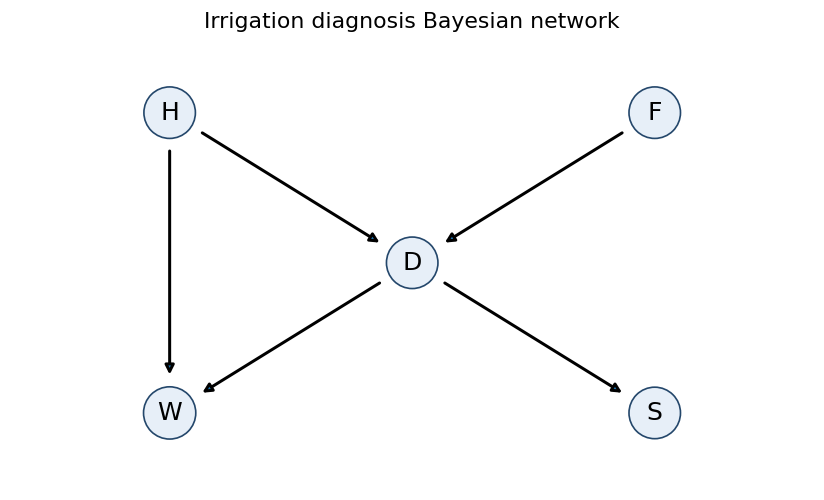

In [3]:
# Draw the actual five-node directed graph without a graph-library dependency.
fig, ax = plt.subplots(figsize=(7, 4.3))
positions = {'H': (-1, 2), 'F': (1, 2), 'D': (0, 1), 'S': (1, 0), 'W': (-1, 0)}
for start, end in [('H', 'D'), ('F', 'D'), ('D', 'S'), ('D', 'W'), ('H', 'W')]:
    ax.annotate('', xy=positions[end], xytext=positions[start],
                arrowprops={'arrowstyle': '-|>', 'lw': 1.8, 'shrinkA': 23, 'shrinkB': 23})
for name, xy in positions.items():
    ax.text(*xy, name, ha='center', va='center', fontsize=15,
            bbox={'boxstyle': 'circle,pad=0.55', 'fc': '#e7eff8', 'ec': '#24476b'})
ax.set(xlim=(-1.65, 1.65), ylim=(-0.5, 2.5), title='Irrigation diagnosis Bayesian network')
ax.axis('off')
fig.tight_layout()
fig.savefig(OUT / 'network.png', dpi=200)
plt.show()

In [4]:
def enumerate_joint():
    """Evaluate every one of the 2**5 complete states using the factorisation."""
    rows = []
    for bits in product((0, 1), repeat=len(ORDER)):
        state = dict(zip(ORDER, bits))
        probability = 1.0
        for variable in ORDER:
            probability *= float(value_probability(state[variable], probability_one(variable, state)))
        rows.append({**state, 'joint_probability': probability})
    return pd.DataFrame(rows)

def exact_query(joint, evidence):
    """Return P(F=1 | evidence) and the evidence probability."""
    matches = np.ones(len(joint), dtype=bool)
    for variable, observed in evidence.items():
        matches &= joint[variable].to_numpy() == observed
    denominator = joint.loc[matches, 'joint_probability'].sum()
    numerator = joint.loc[matches & (joint['F'] == 1), 'joint_probability'].sum()
    return (numerator / denominator if denominator > 0 else np.nan), denominator

joint = enumerate_joint()
assert len(joint) == 32
assert np.isclose(joint['joint_probability'].sum(), 1.0, atol=1e-12, rtol=0)
exact = pd.DataFrame([
    {'query': name, 'exact': exact_query(joint, evidence)[0],
     'evidence_probability': exact_query(joint, evidence)[1]}
    for name, evidence in QUERIES.items()
]).set_index('query')
EXACT = exact['exact'].to_dict()
print('Joint sum:', joint['joint_probability'].sum())
print(exact.to_string(float_format=lambda x: f'{x:.9f}'))
joint.to_csv(OUT / 'exact_joint_32_states.csv', index=False)
exact.to_csv(OUT / 'exact_queries.csv')

Joint sum: 1.0
            exact  evidence_probability
query                                  
q1    0.231503580           0.268160000
q2    0.293293831           0.159316000
q3    0.168674699           0.109560000


## 2. Independently check the exact answers

A sampler and enumerator sharing the same incorrect CPT lookup can agree for the wrong reason.
The next check instead sums out D analytically for each (H,F) pair, using separately entered decimal values
and exact rational arithmetic. It also checks the root marginals and the sensor's conditional independence.
This is a numerical cross-check of the implementation, not a substitute for comparing the CPTs with your assignment.

In [5]:
from fractions import Fraction as Q

def independent_reference(evidence):
    """Analytically marginalise D and unused S/W; do not call the CPT helper."""
    dry = {(0, 0): Q('0.05'), (0, 1): Q('0.80'), (1, 0): Q('0.40'), (1, 1): Q('0.95')}
    numerator, denominator = Q(0), Q(0)
    for h, f in product((0, 1), repeat=2):
        if 'H' in evidence and h != evidence['H']:
            continue
        ph = Q('0.30') if h else Q('0.70')
        pf = Q('0.08') if f else Q('0.92')
        p_d = dry[h, f]
        if 'W' in evidence:
            w_dry = Q('0.90') if h else Q('0.70')
            w_wet = Q('0.10') if h else Q('0.02')
            likelihood = p_d * Q('0.90') * w_dry + (1-p_d) * Q('0.10') * w_wet
        else:
            likelihood = p_d * Q('0.90') + (1-p_d) * Q('0.10')
        mass = ph * pf * likelihood
        denominator += mass
        numerator += f * mass
    return float(numerator / denominator), float(denominator)

for name, evidence in QUERIES.items():
    reference, evidence_probability = independent_reference(evidence)
    assert np.isclose(reference, EXACT[name], atol=1e-12, rtol=0)
    assert np.isclose(evidence_probability, exact.loc[name, 'evidence_probability'], atol=1e-12, rtol=0)
for variable, expected in [('H', P_H), ('F', P_F)]:
    assert np.isclose(joint.loc[joint[variable] == 1, 'joint_probability'].sum(), expected)
for h, f, d, w in product((0, 1), repeat=4):
    subset = joint[(joint.H == h) & (joint.F == f) & (joint.D == d) & (joint.W == w)]
    sensor_probability = subset.loc[subset.S == 1, 'joint_probability'].sum() / subset['joint_probability'].sum()
    assert np.isclose(sensor_probability, S_CPT[d])
print('Passed: independent exact calculations, root marginals and sensor independence.')

Passed: independent exact calculations, root marginals and sensor independence.


## 3. Forward sampling and rejection — A2

Generate H, F, D, S and W in that order. Parents are always available before their children.
For probability p, draw $U\sim\operatorname{Uniform}[0,1)$ and set $X=1$ if $U<p$, otherwise set $X=0$.
The interval below p has length p, so this produces a Bernoulli outcome with success probability p.

For example, when H=1 and F=0, D uses p=0.40. A draw of 0.27 produces dry soil; 0.83 does not.
The vectorised code processes N independent worlds together but still visits the nodes in topological order.

To condition on evidence, keep only worlds matching it:

$$\widehat P(F=1\mid e)=\frac{\sum_i\mathbf1[F_i=1,E_i=e]}{\sum_i\mathbf1[E_i=e]}.$$

An empty retained set produces `NaN` (undefined), not zero. One forward sample set can serve all three queries.

In [6]:
def forward_sample(n, rng):
    """Input: sample count and RNG. Output: one integer array of length n per node."""
    values = {}
    for variable in ORDER:
        p = probability_one(variable, values)
        values[variable] = (rng.random(n) < p).astype(np.int8)
    return values

def rejection_estimate(samples, evidence):
    """Filter complete samples; return the estimate and retained count."""
    keep = np.ones(len(samples['F']), dtype=bool)
    for variable, observed in evidence.items():
        keep &= samples[variable] == observed
    retained = int(keep.sum())
    estimate = float(samples['F'][keep].mean()) if retained else np.nan
    return estimate, retained

small = forward_sample(10, np.random.default_rng(123))
print(pd.DataFrame(small).to_string(index=False))
print('q2 estimate and retained count for this tiny demo:', rejection_estimate(small, QUERIES['q2']))
# A constructed empty-evidence case checks the required undefined behaviour.
empty_match = {variable: np.zeros(4, dtype=np.int8) for variable in ORDER}
assert np.isnan(rejection_estimate(empty_match, {'S': 1})[0])

 H  F  D  S  W
 0  0  0  0  0
 1  0  1  1  1
 1  0  0  0  0
 1  0  0  0  0
 1  0  1  1  1
 0  0  1  1  1
 0  0  0  0  1
 1  0  0  0  1
 0  0  0  0  0
 0  0  0  0  0
q2 estimate and retained count for this tiny demo: (0.0, 3)


## 4. Likelihood weighting — A3

Fix the observed nodes to their evidence values, sample the other nodes in topological order, and multiply
each sample's weight by the probability of each observed value given its parents.

$$w_i=\prod_{E_j\in E}P(E_j=e_j\mid\operatorname{parents}(E_j)_i),\qquad
\widehat P(F=1\mid e)=\frac{\sum_i w_i\mathbf1[F_i=1]}{\sum_i w_i}.$$

For q2, $w_i=P(S=1\mid D_i)P(W=1\mid H_i,D_i)$.
For q3, the weight also includes $P(H=1)=0.30$; this constant cancels in the normalised estimate,
but keeping it makes the evidence-probability check valid.

Why weight? Clamping the sensor to 1 does not by itself make upstream faults more frequent.
Weights correct for the evidence likelihood omitted by the proposal sampler. Plain, unweighted fault counts
would still tend to 0.08 here because F is sampled directly from its prior.

Weight diagnostics:
- Effective sample size: $\mathrm{ESS}=(\sum_i w_i)^2/\sum_i w_i^2$.
- Largest normalised weight: $\max_i w_i/\sum_i w_i$.
- Fraction of total weight carried by the largest 1% of weights.

ESS is a weight-concentration diagnostic, not a literal count of independent posterior draws or a guarantee of accuracy.

In [7]:
def likelihood_weighted_sample(n, evidence, rng):
    """Return assigned values and n unnormalised importance weights."""
    values = {}
    weights = np.ones(n, dtype=float)
    for variable in ORDER:
        p = probability_one(variable, values)
        if variable in evidence:
            observed = evidence[variable]
            values[variable] = np.full(n, observed, dtype=np.int8)
            weights *= value_probability(observed, p)
        else:
            values[variable] = (rng.random(n) < p).astype(np.int8)
    return values, weights

def weighted_estimate(samples, weights):
    """Normalise weighted fault counts; protect against zero total weight."""
    total = float(weights.sum())
    return float(np.sum(weights * samples['F']) / total) if total > 0 else np.nan

def weight_diagnostics(weights):
    total = float(weights.sum())
    if total == 0:
        return {'ess': 0.0, 'ess_fraction': 0.0, 'max_normalised_weight': np.nan, 'top_1pct_weight_share': np.nan}
    ess = total ** 2 / float(np.sum(weights ** 2))
    k = max(1, int(np.ceil(0.01 * len(weights))))
    top_share = float(np.partition(weights, len(weights)-k)[-k:].sum() / total)
    return {'ess': ess, 'ess_fraction': ess / len(weights),
            'max_normalised_weight': float(weights.max() / total), 'top_1pct_weight_share': top_share}

# Tiny deterministic fixtures test weighting and normalisation independently of randomness.
assert np.isclose(weighted_estimate({'F': np.array([0, 1])}, np.array([1.0, 3.0])), 0.75)
assert np.isclose(weighted_estimate({'F': np.array([0, 1])}, np.array([10.0, 30.0])), 0.75)
assert np.isnan(weighted_estimate({'F': np.array([0, 1])}, np.zeros(2)))
for h, f, d in product((0, 1), repeat=3):
    fixed = {'H': h, 'F': f, 'D': d, 'S': 1, 'W': 1}
    values, weights = likelihood_weighted_sample(1, fixed, np.random.default_rng(0))
    row = joint[(joint.H == h) & (joint.F == f) & (joint.D == d) & (joint.S == 1) & (joint.W == 1)]
    assert np.isclose(weights[0], row['joint_probability'].iloc[0])
print('Passed: weighted-count fixture, scale invariance, zero weights, all-fixed joint weights.')

Passed: weighted-count fixture, scale invariance, zero weights, all-fixed joint weights.


## 5. Pause and predict before running the experiment

Edit this Markdown cell **before** running the next section. If you already viewed the saved results, say so;
do not label a statement made after seeing results as a prior prediction. You can instead predict what will
happen in an additional seed run and test it separately from the required experiment.

- My prediction about q1 versus q2: **[write your prediction and reason]**
- My prediction about q2 versus q3: **[write your prediction and reason]**
- My prediction about rejection versus likelihood weighting: **[write your prediction and reason]**
- What I expect when N increases: **[write your prediction and reason]**
- Date and whether I had already seen these outputs: **[complete]**

The required runs use N = 1,000, 10,000 and 100,000, with five independent seed streams at each size.
Each (method, size, run, query) stream is keyed reproducibly using NumPy SeedSequence.
Rejection deliberately shares one sample set across the three queries; likelihood weighting uses a separate
sample set for each evidence pattern. Runs at different N are not nested prefixes of each other.

In [8]:
SAMPLE_SIZES = [1_000, 10_000, 100_000]
SEEDS = [11, 23, 37, 51, 79]

def make_rng(seed, n, method_id, query_id=0):
    # Keep the seed components in the output table so every stream is reproducible.
    return np.random.default_rng(np.random.SeedSequence([seed, n, method_id, query_id]))

# One small warm-up per implementation; excluded from all measured experiment times.
forward_sample(100, make_rng(999, 100, 0))
likelihood_weighted_sample(100, QUERIES['q2'], make_rng(999, 100, 1))
rows, timing_rows = [], []
for n in SAMPLE_SIZES:
    for seed in SEEDS:
        rng = make_rng(seed, n, 0)
        start = perf_counter()
        samples = forward_sample(n, rng)
        sample_seconds = perf_counter() - start
        filtering_total = 0.0
        for query, evidence in QUERIES.items():
            start = perf_counter()
            estimate, retained = rejection_estimate(samples, evidence)
            filter_seconds = perf_counter() - start
            filtering_total += filter_seconds
            rows.append({'method': 'Rejection', 'N': n, 'seed': seed, 'rng_key': str([seed, n, 0, 0]),
                         'query': query, 'estimate': estimate, 'retained': retained,
                         'retained_fraction': retained/n, 'sample_seconds_shared': sample_seconds,
                         'query_seconds': filter_seconds,
                         'evidence_probability_estimate': retained/n})
        timing_rows.append({'method': 'Rejection', 'N': n, 'seed': seed,
                            'all_queries_seconds': sample_seconds + filtering_total,
                            'random_bernoulli_draws': 5*n, 'cpt_evaluations': 5*n})
        lw_total = 0.0
        for query_id, (query, evidence) in enumerate(QUERIES.items(), start=1):
            rng = make_rng(seed, n, 1, query_id)
            start = perf_counter()
            weighted_samples, weights = likelihood_weighted_sample(n, evidence, rng)
            estimate = weighted_estimate(weighted_samples, weights)
            elapsed = perf_counter() - start
            lw_total += elapsed
            # Diagnostics are computed outside the inference timer for both methods.
            diagnostics = weight_diagnostics(weights)
            assert all(np.all(weighted_samples[v] == value) for v, value in evidence.items())
            rows.append({'method': 'Likelihood weighting', 'N': n, 'seed': seed,
                         'rng_key': str([seed, n, 1, query_id]), 'query': query,
                         'estimate': estimate, 'query_seconds': elapsed,
                         'evidence_probability_estimate': float(weights.mean()), **diagnostics})
        timing_rows.append({'method': 'Likelihood weighting', 'N': n, 'seed': seed,
                            'all_queries_seconds': lw_total,
                            'random_bernoulli_draws': 9*n, 'cpt_evaluations': 15*n})

results = pd.DataFrame(rows)
results['exact'] = results['query'].map(EXACT)
results['absolute_error'] = (results['estimate'] - results['exact']).abs()
timings = pd.DataFrame(timing_rows)
assert len(results) == 90  # 2 methods x 3 sizes x 5 seeds x 3 queries
assert results.groupby(['method', 'N', 'query']).size().eq(5).all()
assert results['estimate'].dropna().between(0, 1).all()
print(f'Completed {len(results)} query estimates and {len(timings)} timing records.')
results.to_csv(OUT / 'per_run_results.csv', index=False)
timings.to_csv(OUT / 'per_run_timings.csv', index=False)

Completed 90 query estimates and 30 timing records.


## 6. Compare accuracy and effort — A4

The standard deviation below is the **sample standard deviation across five estimates** (ddof=1).
Mean absolute error is the average absolute distance of each estimate from the exact reference.
It is not the absolute error of the mean estimate. Undefined runs would be excluded from numerical
summaries and counted explicitly in `undefined_runs`.

Timing compares the complete three-query workload. Rejection's shared sampling cost is counted once.
The likelihood-weighting implementation generates four, three and two non-evidence values per sample
for q1, q2 and q3: a total of 9N random draws, versus 5N for the reused forward sample set.
Both use five node probability evaluations per generated world, including fixed evidence likelihoods.
These operation counts supplement noisy wall-clock timings; neither method is assumed universally faster.
RNG setup, diagnostic calculations, assertions, plots and file saving are excluded from inference times.

In [9]:
summary = results.groupby(['method', 'N', 'query'], sort=False).agg(
    exact=('exact', 'first'), mean_estimate=('estimate', 'mean'),
    standard_deviation=('estimate', 'std'), mean_absolute_error=('absolute_error', 'mean'),
    defined_runs=('estimate', 'count'), mean_retained=('retained', 'mean'),
    mean_retained_fraction=('retained_fraction', 'mean'), mean_ess_fraction=('ess_fraction', 'mean'),
    mean_max_weight=('max_normalised_weight', 'mean'), mean_top_1pct_share=('top_1pct_weight_share', 'mean')
).reset_index()
summary['undefined_runs'] = len(SEEDS) - summary['defined_runs']
print(summary[['method', 'N', 'query', 'exact', 'mean_estimate', 'standard_deviation',
               'mean_absolute_error', 'undefined_runs']].to_string(index=False, float_format=lambda x: f'{x:.6f}'))
summary.to_csv(OUT / 'summary.csv', index=False)
timing_summary = timings.groupby(['method', 'N'], sort=False).agg(
    mean_seconds=('all_queries_seconds', 'mean'), std_seconds=('all_queries_seconds', 'std'),
    random_bernoulli_draws=('random_bernoulli_draws', 'first'), cpt_evaluations=('cpt_evaluations', 'first')
).reset_index()
print('\nThree-query workload timing:')
print(timing_summary.to_string(index=False, float_format=lambda x: f'{x:.6f}'))
timing_summary.to_csv(OUT / 'timing_summary.csv', index=False)

              method      N query    exact  mean_estimate  standard_deviation  mean_absolute_error  undefined_runs
           Rejection   1000    q1 0.231504       0.217780            0.026704             0.025985               0
           Rejection   1000    q2 0.293294       0.276793            0.041487             0.037454               0
           Rejection   1000    q3 0.168675       0.161360            0.065765             0.046095               0
Likelihood weighting   1000    q1 0.231504       0.242856            0.045430             0.040452               0
Likelihood weighting   1000    q2 0.293294       0.280745            0.025065             0.022485               0
Likelihood weighting   1000    q3 0.168675       0.172858            0.012183             0.009808               0
           Rejection  10000    q1 0.231504       0.229340            0.011227             0.009802               0
           Rejection  10000    q2 0.293294       0.290926            0.011364   

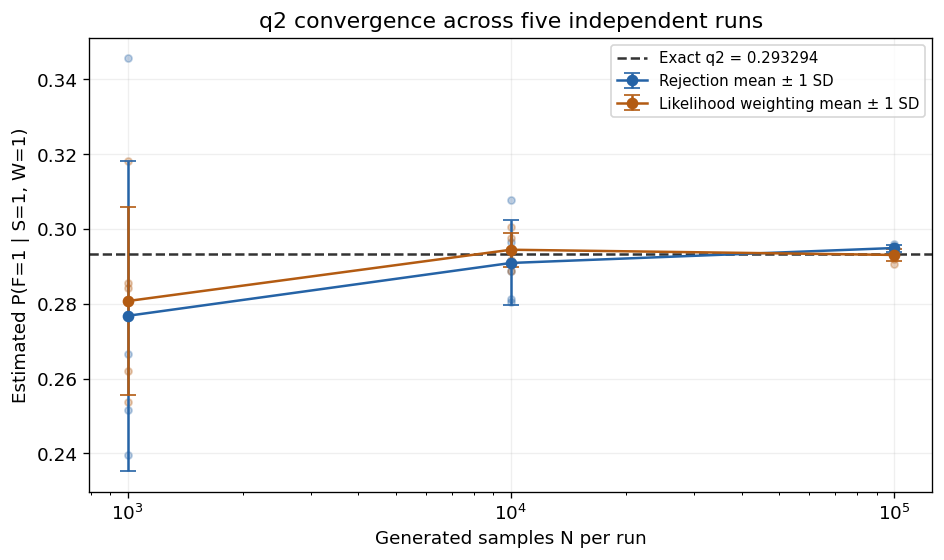

Large-N efficiency diagnostics:
              method query  mean_retained_fraction  mean_ess_fraction  mean_max_weight  mean_top_1pct_share
           Rejection    q1                0.267508                NaN              NaN                  NaN
           Rejection    q2                0.158956                NaN              NaN                  NaN
           Rejection    q3                0.109432                NaN              NaN                  NaN
Likelihood weighting    q1                     NaN           0.403679         0.000034             0.033554
Likelihood weighting    q2                     NaN           0.215415         0.000051             0.050799
Likelihood weighting    q3                     NaN           0.458086         0.000022             0.022163

Theoretical rejection retention fractions:
query
q1   0.268160
q2   0.159316
q3   0.109560


In [10]:
fig, ax = plt.subplots(figsize=(8, 4.8))
colors = {'Rejection': '#2563a6', 'Likelihood weighting': '#b35b12'}
for method, color in colors.items():
    points = summary[(summary['method'] == method) & (summary['query'] == 'q2')].sort_values('N')
    ax.errorbar(points['N'], points['mean_estimate'], yerr=points['standard_deviation'],
                marker='o', capsize=5, color=color, label=method + ' mean ± 1 SD')
    runs = results[(results['method'] == method) & (results['query'] == 'q2')]
    ax.scatter(runs['N'], runs['estimate'], color=color, alpha=0.3, s=18)
ax.axhline(EXACT['q2'], color='#333333', linestyle='--', label=f"Exact q2 = {EXACT['q2']:.6f}")
ax.set(xscale='log', xlabel='Generated samples N per run', ylabel='Estimated P(F=1 | S=1, W=1)',
       title='q2 convergence across five independent runs')
ax.grid(alpha=0.2)
ax.legend(fontsize=9)
fig.tight_layout()
fig.savefig(OUT / 'q2_convergence.png', dpi=200)
fig.savefig(OUT / 'q2_convergence.pdf')
plt.show()

print('Large-N efficiency diagnostics:')
print(summary[summary.N == max(SAMPLE_SIZES)][
    ['method', 'query', 'mean_retained_fraction', 'mean_ess_fraction', 'mean_max_weight', 'mean_top_1pct_share']
].to_string(index=False, float_format=lambda x: f'{x:.6f}'))
print('\nTheoretical rejection retention fractions:')
print(exact['evidence_probability'].to_string(float_format=lambda x: f'{x:.6f}'))

## 7. Interpret the results in your own words

Use the printed exact values to ground these explanations:

- **q1 to q2:** wilting provides additional evidence of a condition consistent with dry soil, making a
  sensor false alarm a less complete explanation. Under these CPTs, the fault probability increases.
- **q2 to q3:** known hot weather supplies another explanation for dry soil and wilting, so the fault
  probability decreases. This is evidence-dependent reasoning under the given model, not proof of causation.
- **Larger N:** repeated-run accuracy is expected to improve as sampling error shrinks, but an individual
  larger run can be less accurate by chance. Five seeds provide only a small sample of run-to-run variability.
- **Rejection:** compare retained fractions with the exact evidence probabilities. Rare evidence wastes
  more generated worlds. Small retained counts also make the estimate more variable.
- **Likelihood weighting:** interpret ESS/N, the largest normalised weight and the top-1% share together.
  Unequal weights reduce effective information; quantify their concentration rather than claiming all
  N samples contribute equally. No one diagnostic proves which estimator has lower error.
- **Effort:** use the three-query workload times and operation counts, remembering that the rejection
  implementation reuses joint worlds across queries and the weighted method uses separate evidence-specific runs.

Complete after your run:

1. q1 = **[value]**, q2 = **[value]**, q3 = **[value]**.
2. At N=100,000, the q2 mean absolute errors were **[values]**.
3. The q3 rejection retained fraction was **[value]**, compared with exact evidence probability **[value]**.
4. The weighted q3 ESS/N and largest normalised weight were **[values]**; this suggests **[interpretation]**.
5. The complete workload times were **[values]** on **[your runtime]**.
6. My prediction was **[prediction]**. I observed **[specific evidence]**, so I **[accepted/revised]** it.

In about two report pages, include the graph/factorisation and independence, method explanations, settings,
compact accuracy table, q2 plot, and the evidence/effort discussion. Put detailed per-run results in the ZIP.
Do not use the supplement to hide essential answers beyond the ten-page report limit.

## 8. Reproduction information and AI-use record

Main functions to explain:

| Function | Inputs | Output and purpose |
|---|---|---|
| `enumerate_joint` | CPTs in notebook | 32-row exact joint distribution |
| `forward_sample` | N and RNG | Complete simulated worlds |
| `rejection_estimate` | Worlds and evidence | Conditional estimate and retained count |
| `likelihood_weighted_sample` | N, evidence and RNG | Assigned worlds and importance weights |
| `weighted_estimate` | Worlds and weights | Normalised posterior fault estimate |

Sources checked for this notebook:
- Your COMP6010 2026 assignment brief: model, experiments and submission requirements.
- Your unit's Bayesian-network lectures: **add the exact lecture titles/pages you consult**.
- [UC Berkeley CS188 — Approximate inference](https://inst.eecs.berkeley.edu/~cs188/textbook/bayes-nets/approximate.html): sampling and evidence weighting.
- [NumPy — Random Generator](https://numpy.org/doc/stable/reference/random/generator.html): generator API; package versions are recorded below.
- [Google Colab FAQ](https://research.google.com/colaboratory/faq.html): notebook/runtime storage and resource behaviour.

Reference access date for the assistant's verification: 12 September 2026.

Keep 3–5 selected AI interactions across the assignment. The exported template starts with this interaction
and leaves your own checks and decisions blank. Do not claim to have personally performed the assistant's
verification. Record the model label you can actually see rather than guessing its version.

In [11]:
configuration = {
    'assignment': 'COMP6010 2026 Part A', 'sample_sizes': SAMPLE_SIZES, 'seeds': SEEDS,
    'rng': 'numpy.default_rng(SeedSequence([seed, N, method_id, query_id]))',
    'method_ids': {'rejection': 0, 'likelihood_weighting': 1},
    'query_ids': {'rejection_shared': 0, 'weighted_q1': 1, 'weighted_q2': 2, 'weighted_q3': 3},
    'queries': QUERIES, 'order': ORDER, 'root_probabilities': {'H': P_H, 'F': P_F},
    'D_CPT_rows_H_columns_F': D_CPT.tolist(), 'S_CPT_index_D': S_CPT.tolist(),
    'W_CPT_rows_H_columns_D': W_CPT.tolist(), 'versions': VERSIONS,
    'python': sys.version, 'platform': platform.platform(),
    'processor': platform.processor(), 'cpu_count': __import__('os').cpu_count(),
    'timing_scope': 'All three queries; no RNG setup, diagnostics, assertions, plotting or saving.',
    'measured_sum_of_inference_seconds': float(timings['all_queries_seconds'].sum())
}
(OUT / 'configuration.json').write_text(json.dumps(configuration, indent=2))
(OUT / 'requirements_observed.txt').write_text('\n'.join(f'{k}=={v}' for k, v in VERSIONS.items()) + '\n')
readme = """COMP6010 Part A results

Run the guided notebook from top to bottom in Python 3 with numpy, pandas and matplotlib.
No dataset, GPU, checkpoint or API access is needed for this part.
requirements_observed.txt records the versions actually used for this export.
configuration.json records CPTs, stream keys, hardware information and measured inference time.
Inference takes seconds on an ordinary CPU; notebook startup and figure rendering add overhead.
Measured wall-clock time depends on the machine and current load.

Files:
- exact_joint_32_states.csv and exact_queries.csv: correctness references.
- per_run_results.csv: all 90 estimates, diagnostics and exact-reference errors.
- summary.csv: means, sample standard deviations and mean absolute errors.
- per_run_timings.csv and timing_summary.csv: all-three-query cost with shared sampling counted once.
- network.png and q2_convergence.png/pdf: report figures.
- ai_use_log_template.md: complete with your actual verification and decisions.

Save the notebook WITH OUTPUTS separately and include it beside these files in the final supplement.
This export contains Part A only; it is not the complete assignment supplement.
Source model: COMP6010_Assignment_2026.docx. No external datasets or private information are included.
"""
(OUT / 'README.txt').write_text(readme)
log_path = OUT / 'ai_use_log_template.md'
if not log_path.exists():
    log_path.write_text("""# AI-use log to complete

## Interaction 1
- Date: 12 September 2026 (confirm your session date).
- Tool/model: ChatGPT; add the exact model label if visible.
- User prompt: 'ill be running in colab lets start'
- Assistance received: guided Part A notebook, explanations, sampling implementation and assistant-side checks.
- Relevant response excerpt: 'I’ll start with a Colab notebook for Part A, with explanations, both samplers, and checks against the exact answers.'
- Assistant verification: numerical comparison with an independent rational-arithmetic reference; deterministic estimator checks; complete experiment execution.
- My independent check: [complete after personally checking a CPT, calculation, source or output].
- Evidence or source used for my check: [complete].
- My resulting decision or code change: [complete].

## Prediction versus observation
- Prediction and reason, recorded before a new run: [complete].
- Had I already seen earlier saved outputs? [state honestly].
- Setting/seed to test: [complete].
- Observed result and evidence file: [complete].
- Decision or revision: [complete].

Add selected interactions for Parts B and C to reach 3–5 across the assignment.
""")
archive = shutil.make_archive('COMP6010_Part_A_results', 'zip', root_dir=OUT)
print('Export created:', archive)
print('Measured total inference seconds:', configuration['measured_sum_of_inference_seconds'])
print('Download the results ZIP and separately save this notebook with its outputs.')

Export created: /content/COMP6010_Part_A_results.zip
Measured total inference seconds: 0.34651669100094296
Download the results ZIP and separately save this notebook with its outputs.


In [12]:
# In Colab, set this to True and run the cell to download the generated results ZIP.
# It is False by default so Run all never triggers an unexpected browser download.
DOWNLOAD_RESULTS = False
if DOWNLOAD_RESULTS:
    try:
        from google.colab import files
        files.download(archive)
    except ImportError:
        print('Outside Colab: retrieve the ZIP from the working directory:', archive)

## Before moving to Part B

Confirm all assertions passed, inspect the graph and q2 plot, complete the interpretation and AI-use prompts,
and download your executed notebook and result ZIP. Colab runtime files are temporary; keep your copies.
In Part B we will learn an unknown parameter with a Beta prior instead of treating all model probabilities as known.